In [147]:
# Transformers example -> Reverseing sequence of numbers


In [7]:
import jax
import jax.numpy as jnp
import jax.random as jrandom
import matplotlib.pyplot as plt

import haiku as hk
import optax

from probjax.utils.odeint import _odeint

from probjax.nn.transformers import Transformer, LearnedPosEmbed, PosEmbed

In [8]:
jax.devices()

[CpuDevice(id=0)]

In [9]:
def generate_data(key, n):
    theta1 = jrandom.normal(key, (n, 1))
    x1 = 2*theta1 + 10 + jrandom.normal(key, (n, 1)) * 0.1
    x2 = .3*theta1 + 15 + jrandom.normal(key, (n, 1)) * 0.1
    return jnp.concatenate([theta1,x1, x2], axis=1).reshape(n, -1, 1)


data = generate_data(jrandom.PRNGKey(1), 10000)

T_max = data.shape[1]

node_ids = jnp.arange(T_max)

In [10]:
key = jrandom.PRNGKey(0)

In [11]:
from probjax.nn.helpers import TimeEmbedding

In [49]:

def model(node_ids):
    
    # Embed
    dim = 50
    #embedding_net = hk.Linear(dim)
    embedding_id_nets = hk.Embed(T_max, dim)
    #embedding_condition_nets = hk.Embed(T_max, dim)


    model = Transformer(num_heads=1, num_layers=1, attn_size=dim, dropout_rate=0.0, widening_factor=2)

    node_ids = node_ids.reshape(-1, T_max)
    id_embeddings = embedding_id_nets(node_ids)

    x_encoded = id_embeddings
    
    # Encode
    h = model(x_encoded)
    out = hk.Linear(2)(h)
    mean, std = out[..., 0], out[..., 1]
    std = jax.nn.softplus(std) + 1e-6


    return mean, std


In [50]:
init, model_fn = hk.transform(model)
params = init(key, node_ids)

In [52]:
optimizer = optax.adam(1e-3)
opt_state = optimizer.init(params)

In [60]:

def loss_fn(params, key, batch_size= 1000):
    key_data, key_model = jrandom.split(key)
    batch_xs = generate_data(key_data, batch_size) # n, T_max, 1

    key_data, key_model = jrandom.split(key)
    mean, std = model_fn(params, key_model, node_ids)

    loss = - jax.scipy.stats.norm.logpdf(batch_xs, mean,std).sum(axis=1).mean()
    return loss


@jax.jit
def update(params, rng, opt_state):
    loss, grads = jax.value_and_grad(loss_fn)(params, rng)
    updates, opt_state = optimizer.update(grads, opt_state)
    params = optax.apply_updates(params, updates)
    return loss, params, opt_state

In [61]:
iters_per_epoch = 1000
for e in range(100):
    full_loss = 0
    for i in range(iters_per_epoch):
        key = jrandom.PRNGKey(i)
        loss, params, opt_state = update(params, key, opt_state)
        full_loss += loss
        
    print(full_loss/iters_per_epoch)

10.898312
9.817821
9.817798
9.8178
9.817799
9.817803
9.817804
9.81782
9.81783
9.817839
9.817846
9.817854
9.817853
9.817854
9.8178625
9.8178625
9.817858
9.817855


KeyboardInterrupt: 

In [26]:

def sample_fn(params, key, shape, time_steps=100):
    x_T = jax.random.normal(key, shape + (T_max, 1)) * marginal_std(jnp.zeros(shape), 1)
    ts = jnp.linspace(1, 1e-6, time_steps)
    time_steps = ts[0] - ts[1]
    for t in ts:
        time = jnp.ones( (shape[0],1,1), dtype=int) * t
        score = model_fn(params,key+1, time, x_T, node_ids, jnp.zeros_like(node_ids))
        g = diffusion_fn(x_T, t)
        f = drift_fn(x_T, t)
        subkey, key = jax.random.split(key)
        noise = jax.random.normal(subkey, shape + (T_max, 1))
        x_T = x_T - ((f - g**2 * score)*time_steps + g * noise * jnp.sqrt(time_steps))
    return x_T

In [27]:
samples = sample_fn(params, jrandom.PRNGKey(0), (100, ))

In [28]:
from sbi.analysis import pairplot
import numpy as np

(<Figure size 1000x1000 with 9 Axes>,
 array([[<Axes: xlabel='dim 1'>, <Axes: >, <Axes: >],
        [<Axes: >, <Axes: xlabel='dim 2'>, <Axes: >],
        [<Axes: >, <Axes: >, <Axes: xlabel='dim 3'>]], dtype=object))

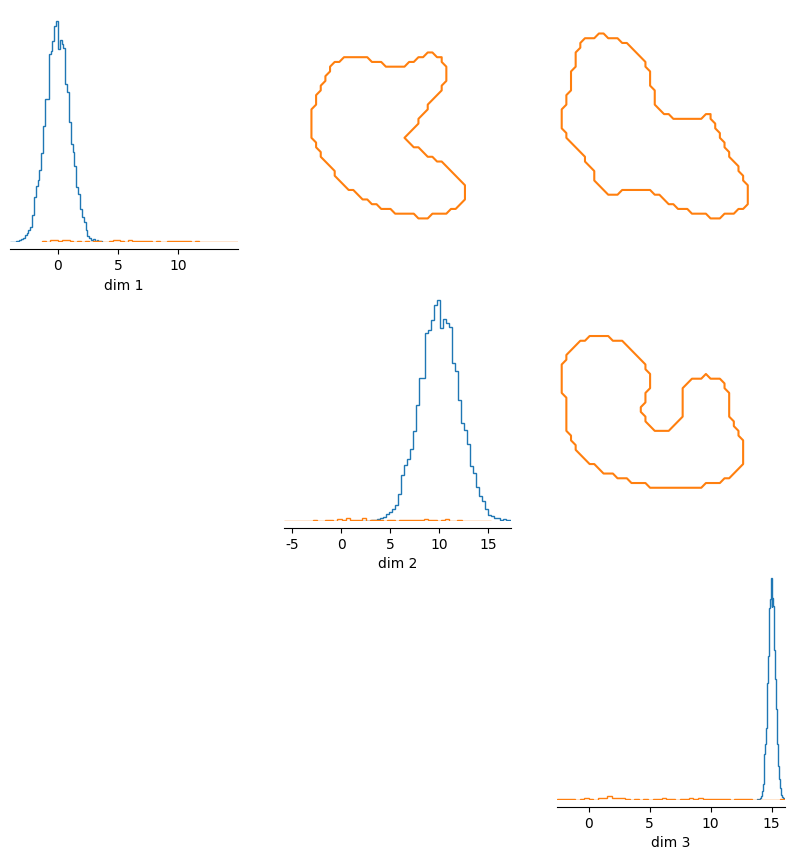

In [29]:
pairplot([np.array(data[...,0]),np.array(samples[...,0])], upper="contour")